# Triangular Laplace--Beltrami equation on the sphere

Triangular-patch benchmark for the surface HPS method.


In [1]:
from pathlib import Path
import sys
import time

import numpy as np

project = Path.cwd().resolve()
if project.name == 'notebooks':
    project = project.parent
sys.path.insert(0, str(project))

import pysurfacefun as psf

output_dir = project / 'notebook_outputs'
output_dir.mkdir(exist_ok=True)


## Geometry

A coarse spherical triangulation is refined once and projected to the unit sphere,

$$\phi(x,y,z)=x^2+y^2+z^2-1.$$


In [2]:
mesh_file = project / 'notebook_data' / 'spher_104.mat'
mesh_refinement = 1

phi = lambda p: p[0]**2 + p[1]**2 + p[2]**2 - 1.0
dphi = lambda p: np.array([2.0*p[0], 2.0*p[1], 2.0*p[2]])

vertices, cells = psf.surface_mesh_arrays(mesh_file, vertex_name='xs', face_name='surfs')
_, refined_cells = psf.refine_surface_mesh(vertices, cells, nref=mesh_refinement, cell_type='tri')

print(f'coarse cells  : {cells.shape[0]}')
print(f'refined cells : {refined_cells.shape[0]}')


coarse cells  : 104
refined cells : 416


In [3]:
def make_domain(n):
    return psf.LevelSetSurface(
        mesh_file,
        phi,
        dphi,
        n=n,
        nref=mesh_refinement,
        vertex_name='xs',
        face_name='surfs',
        orient_outward=True,
    )

dom = make_domain(n=15)
residual_phi = max(
    np.max(np.abs(x*x + y*y + z*z - 1.0))
    for x, y, z in zip(dom.x, dom.y, dom.z)
)
print(f'patches        : {dom.npatches}')
print(f'degree         : {dom.degree}')
print(f'area           : {psf.tri_surfacearea(dom):.12f}')
print(f'max |phi|      : {residual_phi:.3e}')


patches        : 416
degree         : 14
area           : 12.566370614360
max |phi|      : 1.998e-13


## Model problem

On the unit sphere,

$$\Delta_\Gamma Y_\ell^m = -\ell(\ell+1)Y_\ell^m.$$

The manufactured solution is $u=Y_{20}^{10}$.


In [4]:
l, m = 20, 10

def exact_solution(dom):
    return psf.tri_surfacefun(
        lambda x, y, z: psf.real_spherical_harmonic(l, m, x, y, z),
        dom,
    )

u_exact = exact_solution(dom)
rhs = -l * (l + 1) * u_exact


## Discrete operator

The reference differentiation matrices use the Proriol-Koornwinder-Dubiner basis.


In [5]:
Du, Dv, K = psf.tri_strong_diffmat(dom.degree, dom.u, dom.v, basis='pkd')
print(f'K shape            : {K.shape}')
print(f'condition number K : {np.linalg.cond(K):.3e}')


K shape            : (120, 120)
condition number K : 8.666e+01


## Solve

The mean is removed because the closed-surface Laplace-Beltrami operator has constants in the nullspace.


In [6]:
L = psf.tri_surfaceop(dom, {'lap': 1.0}, rhs)
L.rankdef = True

t0 = time.perf_counter()
u_h = L.solve().remove_mean()
elapsed = time.perf_counter() - t0

relerr = (u_h - u_exact.remove_mean()).norm_inf() / u_exact.norm_inf()
print(f'relative L_inf error = {relerr:.3e}')
print(f'solve time           = {elapsed:.3f} s')


relative L_inf error = 6.795e-06
solve time           = 0.402 s


## p-refinement

The refined mesh is fixed and the polynomial degree is increased.


In [7]:
n_values = [5,9,13,17,21]
rows = []

for n in n_values:
    dom_n = make_domain(n)
    exact = exact_solution(dom_n)
    rhs_n = -l * (l + 1) * exact

    L_n = psf.tri_surfaceop(dom_n, {'lap': 1.0}, rhs_n)
    L_n.rankdef = True

    t0 = time.perf_counter()
    sol = L_n.solve().remove_mean()
    solve_time = time.perf_counter() - t0

    err = (sol - exact.remove_mean()).norm_inf() / exact.norm_inf()
    rows.append((n, n - 1, dom_n.npatches, psf.tri_surfacearea(dom_n), err, solve_time))
    print(f'n = {n:2d}, p = {n-1:2d}, patches = {dom_n.npatches:3d}, rel error = {err:.3e}, time = {solve_time:.3f} s')


n =  5, p =  4, patches = 416, rel error = 1.675e+00, time = 0.143 s
n =  9, p =  8, patches = 416, rel error = 3.747e-02, time = 0.182 s
n = 13, p = 12, patches = 416, rel error = 1.468e-04, time = 0.272 s
n = 17, p = 16, patches = 416, rel error = 2.607e-07, time = 0.409 s
n = 21, p = 20, patches = 416, rel error = 4.111e-10, time = 0.566 s


## Output


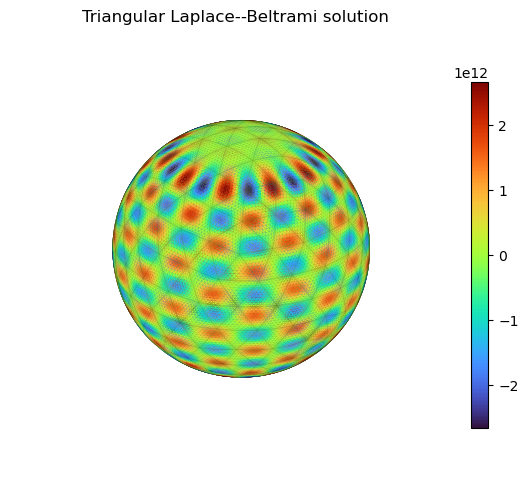

In [8]:
try:
    psf.plot_tri_surface(u_h, title='Triangular Laplace--Beltrami solution')
except Exception as exc:
    print('surface plot skipped:', exc)

psf.write_tri_vtu(output_dir / 'tri_laplace_beltrami_sphere_refined_solution.vtu', u_h, point_name='u_h')


## Reference

G. Zavalani, *A High-Order Fast Direct Solver for Surface PDEs on Triangles*, arXiv:2604.03097, 2026.
